In [59]:
import openseespywin as ops
import opsvis as opsv 
import numpy as np
import ipywidgets as widgets
import os
import matplotlib.pyplot as plt
import math
import opstool as opst
#import eurocodepy as ecpy
import time as tt 
# import openseespy.postprocessing.Get_Rendering as opsplt

In [60]:
import sys
sys.path.append(r"C:\Users\micha\OneDrive\Documents\Python Scripts\open_sees\final_\functions")
import solver_function as SF
import importlib
importlib.reload(SF)
from solver_function import *  

In [61]:
opst.add_ops_hints_file()

OPSTOOL :: opensees.pyi file has been created to 
C:\Users\micha\miniconda3\envs\blue_env\Lib\site-packages\openseespywin\opensees.pyi!

In [62]:
convert_tcl = 'no'
if(convert_tcl=="yes"):
    opst.pre.tcl2py(input_file='create.tcl',
                output_file='create',
                prefix="ops")

In [63]:
length_unit = "m"  # base unit
force_unit = "KN"  # base unit

UNIT = opst.pre.UnitSystem(length=length_unit, force=force_unit)

print("Length:", UNIT.mm, UNIT.mm2, UNIT.cm, UNIT.m,)
print("Force", UNIT.N, UNIT.kN, )
print("Stress", UNIT.MPa, UNIT.kPa, UNIT.Pa, )
print("Mass", UNIT.g, UNIT.kg, UNIT.ton)
print(UNIT)

Length: 0.001 1e-06 0.01 1
Force 0.001 1
Stress 1000.0 1.0 0.001
Mass 1e-06 0.001 1.0
<UnitSystem: length='m', force='kn', time='sec' (145485748625)>


In [64]:
from openseespy.opensees import *
import math
import time

# User-defined variables
massDen = 2.00
fluidDen = 1.0
massProportionalDamping = 0.0
stiffnessProportionalDamping = 0.001
fangle = 31.40
ptangle = 26.50
E = 90000.0
poisson = 0.40
G = E / (2 * (1 + poisson))
B = E / (3 * (1 - 2 * poisson))
press = 0.0
loadIncr = 1.0
deltaT = 0.010
numSteps = 10000
gamma = 0.500
period = 1

pi = math.pi
inclination = 0
unitWeightX = (massDen - fluidDen) * 9.81 * math.sin(math.radians(inclination))
unitWeightY = -(massDen - fluidDen) * 9.81 * math.cos(math.radians(inclination))

ops.wipe()
# ModelBuilder
ops.model('basic', '-ndm', 2, '-ndf', 2)

# Materials
ops.nDMaterial('PressureDependMultiYield02', 2, 2, massDen, G, B, fangle, .1, 80, 0.5, ptangle, 0.17, 0.4, 10, 0, 0.015, 1.0)
ops.nDMaterial('FluidSolidPorous', 1, 2, 2, 2.2e6)

# Nodes
ops.node(1, 0.0, 0.0)
ops.node(2, 1.0, 0.0)
ops.node(3, 1.0, 1.0)
ops.node(4, 0.0, 1.0)

# Element
ops.element('quad', 1, 1, 2, 3, 4, 1.0, "PlaneStrain", 1, press, 0.0, unitWeightX, unitWeightY)

ops.updateMaterialStage('-material', 2, '-stage', 0)

# Fixities
ops.fix(1, 1, 1)
ops.fix(2, 1, 1)
ops.equalDOF(3, 4, 1, 2)

# GRAVITY APPLICATION
ops.system('ProfileSPD')
ops.test('NormDispIncr', 1.e-12, 25, 0)
ops.constraints('Transformation')
ops.integrator('LoadControl', 1, 1, 1, 1)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.analysis('Static')

ops.analyze(2)

newBulk = G * 2 / 3
ops.parameter(1001, 'element', 1, "bulkModulus", '2') #material tag of PDMY MATERIAL

ops.updateMaterialStage('-material', 1, '-stage', 1)
ops.updateMaterialStage('-material', 2, '-stage', 1)
ops.updateParameter(1001, newBulk) 

ops.analyze(1)


Will use 10 yield surfaces.


0

In [65]:
ops.printModel()

Current Domain Information
	Current Time: 3
	Committed Time: 3
NODE DATA: NumNodes: 4

numComponents: 4

 Node: 1
	Coordinates  : 0 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 2
	Coordinates  : 1 0 
	Disps: 0 0 
	 unbalanced Load: 0 0 
	ID : -1 -1 


 Node: 3
	Coordinates  : 1 1 
	Disps: -1.64146e-35 -2.54333e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 


 Node: 4
	Coordinates  : 0 1 
	Disps: -1.64146e-35 -2.54333e-05 
	 unbalanced Load: 0 0 
	ID : 0 1 

ELEMENT DATA: NumEle: 1

numComponents: 1

FourNodeQuad, element id:  1
	Connected external nodes:  1 2 3 4 
	thickness:  1
	surface pressure:  0
	mass density:  0
	body forces:  0 -9.81
FluidSolidPorousMaterial
	Stress (xx yy xy)
		Gauss point 1: -3.27 -4.905 0 
		Gauss point 2: -3.27 -4.905 0 
		Gauss point 3: -3.27 -4.905 0 
		Gauss point 4: -3.27 -4.905 0 

SP_Constraints: numConstraints: 4

numComponents: 4
SP_Constraint: 0	 Node: 1 DOF: 1 ref value: 0 current value: 0 initial value: 0
SP_Constraint: 1	 Node: 1 DOF: 2

In [66]:
opst.vis.plotly.plot_model(show_node_numbering=True, show_ele_numbering=False, show_nodal_loads = True)

In [67]:
# LOADING SEQUENCE
ops.setTime(0.0)
ops.wipeAnalysis()

ops.timeSeries('Linear', 1)
ops.pattern('Plain',1,1)
ops.load(3, loadIncr, 0.0)
accMul = 2.0       # acceleration multiplier
# ops.timeSeries('Sine', 1, 0.0, 10.0, period, "-factor", accMul)
# ops.pattern("UniformExcitation", 1, 1, "-accel",1)


# Recorders
ops.recorder('Node', '-file', 'cdisp.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'disp')
ops.recorder('Node', '-file', 'cacce.out', '-time', '-node', 1, 2, 3, 4, '-dof', 1, 2, '-dT', 0.01, 'accel')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'cstress1.out', '-dT', 0.01, 'material', 1, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'cstrain1.out', '-dT', 0.01, 'material', 1, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'cstress3.out', '-dT', 0.01, 'material', 3, 'stress')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'cstrain3.out', '-dT', 0.01, 'material', 3, 'strain')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'cpress1.out', '-dT', 0.01, 'material', 1, 'pressure')
ops.recorder('Element', '-ele', 1, '-time', '-file', 'cpress3.out', '-dT', 0.01, 'material', 3, 'pressure')

ops.constraints('Transformation')
ops.test('NormDispIncr', 1.e-12, 25, 0)
ops.algorithm('Newton')
ops.numberer('RCM')
ops.system('ProfileSPD')
ops.rayleigh(massProportionalDamping, 0.0, stiffnessProportionalDamping, 0.0)
ops.integrator('Newmark', gamma, (gamma + 0.5)**2 / 4)
ops.analysis('VariableTransient')


ODB = opst.post.CreateODB(
    odb_tag="PDMY09",
    compute_mechanical_measures=True,
    project_gauss_to_nodes="copy",  # "extrapolate", "copy", "average"
)
startT = tt.time()
ops.analyze(numSteps, deltaT, deltaT / 100, deltaT, 10)
ODB.fetch_response_step()
endT = tt.time()

print(f"Execution time: {endT - startT} seconds")

# Wipe model
ODB.save_response(zlib=True)
ops.wipe()

after: 25 iterations  current Norm: 8.20309e-10 (max: 1e-12, Norm deltaR: 0.00172347)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 4.52155e-11 (max: 1e-12, Norm deltaR: 9.93503e-05)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 1.75543e-09 (max: 1e-12, Norm deltaR: 0.00380661)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()
after: 25 iterations  current Norm: 1.87077e-11 (max: 1e-12, Norm deltaR: 4.11291e-05)
NewtonRaphson::solveCurrentStep() -the ConvergenceTest object failed in test()


Execution time: 4.409524917602539 seconds


OPSTOOL ::  All responses data with _odb_tag = PDMY09 saved in .opstool.output/RespStepData-PDMY09.nc!

In [68]:
import matplotlib.pyplot as plt
import opstool as opst
import opstool.vis.pyvista as opsvis
opsvis.set_plot_props(point_size=0, line_width=5, cmap="turbo", notebook=True)
opsvis.set_plot_props(
    scalar_bar_kargs={
        "label_font_size": 12,
        "title_font_size": 13,
        "position_x": 0.85,  # 0--1
    }
)

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-PDMY09.nc ...

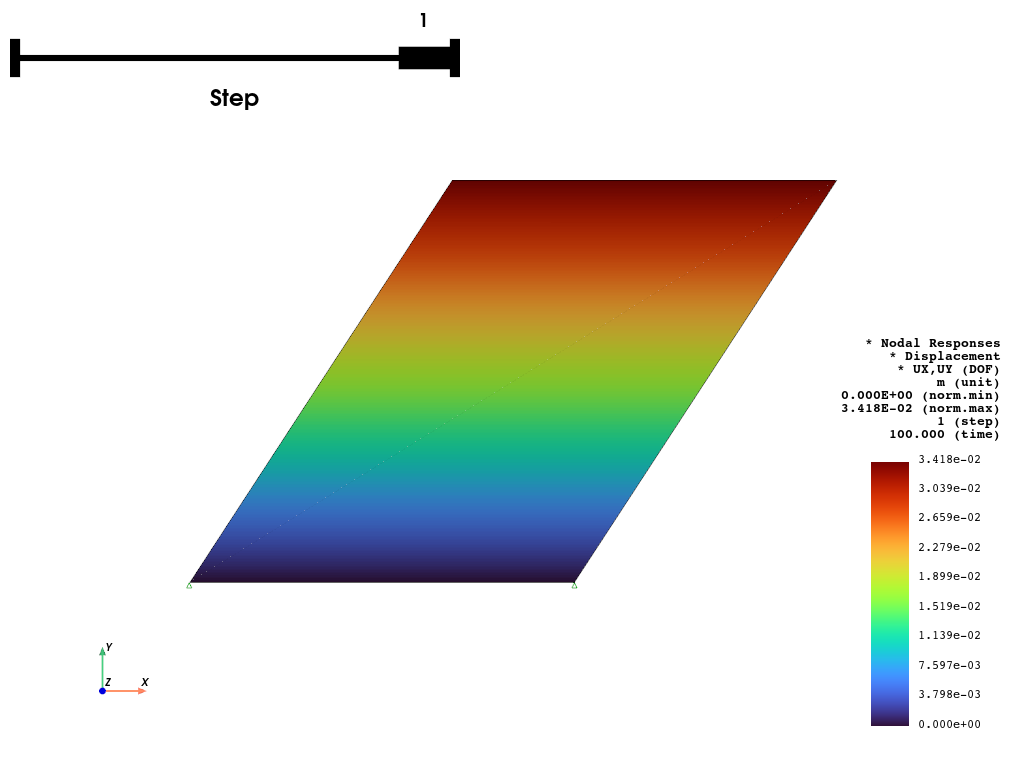

In [69]:
opsvis.plot_nodal_responses(
    odb_tag="PDMY09",
    slides=True,
    defo_scale=20,
    resp_type="disp",
    resp_dof=["UX", "UY"],
    unit_symbol="m",
).show(jupyter_backend="jupyterlab")

OPSTOOL ::  Loading response data from .opstool.output/RespStepData-PDMY09.nc ...

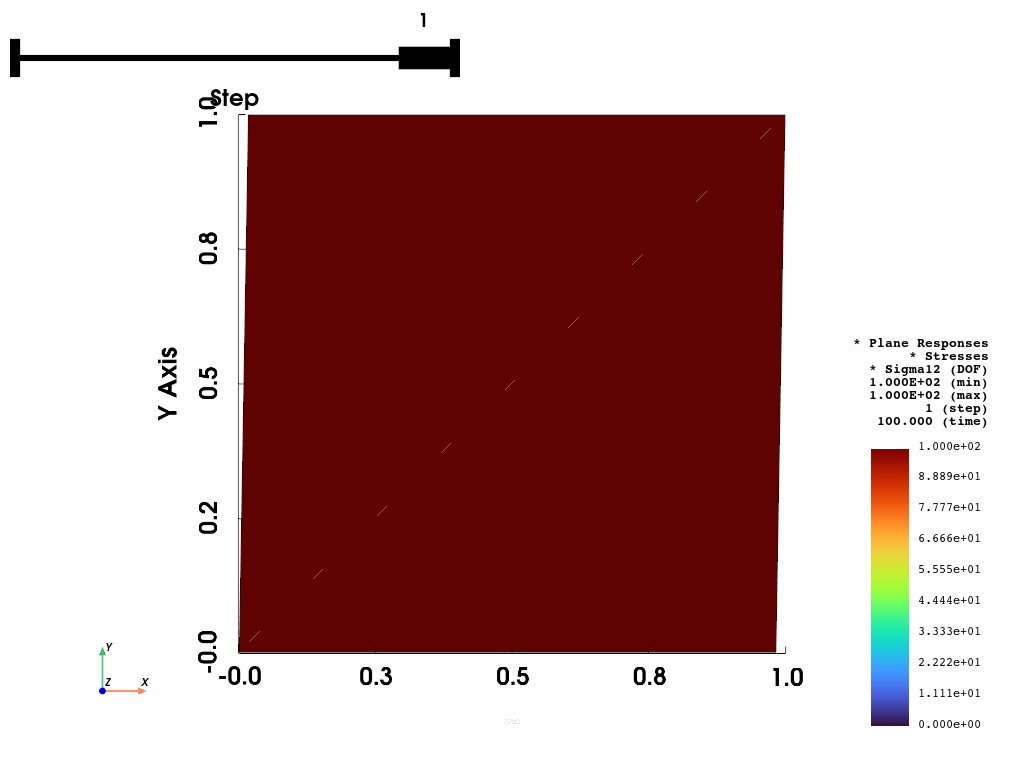

In [70]:
pl = opsvis.plot_unstruct_responses(
    odb_tag="PDMY09", slides=True, ele_type="Plane", resp_type="stresses", resp_dof="sigma12",
    show_defo = True,
    defo_scale = 0.5,
    show_bc = True,
    bc_scale = 0.1,
    show_outline = True,
    show_model = True,
)
pl.show(jupyter_backend="jupyterlab") 

In [71]:
node_resp = opst.post.get_nodal_responses(odb_tag="PDMY09")
print(node_resp)

OPSTOOL ::  Loading all response data from .opstool.output/RespStepData-PDMY09.nc ...

<xarray.Dataset> Size: 1kB
Dimensions:             (time: 2, nodeTags: 4, DOFs: 6)
Coordinates:
  * time                (time) float32 8B 0.0 100.0
  * nodeTags            (nodeTags) int64 32B 1 2 3 4
  * DOFs                (DOFs) <U2 48B 'UX' 'UY' 'UZ' 'RX' 'RY' 'RZ'
Data variables:
    disp                (time, nodeTags, DOFs) float32 192B 0.0 0.0 ... 0.0 0.0
    vel                 (time, nodeTags, DOFs) float32 192B 0.0 0.0 ... 0.0 0.0
    accel               (time, nodeTags, DOFs) float32 192B 0.0 0.0 ... 0.0 0.0
    reaction            (time, nodeTags, DOFs) float32 192B 1.635 4.905 ... 0.0
    reactionIncInertia  (time, nodeTags, DOFs) float32 192B 1.635 4.905 ... 0.0
    rayleighForces      (time, nodeTags, DOFs) float32 192B 0.0 0.0 ... 0.0 0.0
    pressure            (time, nodeTags) float32 32B 0.0 0.0 0.0 ... 0.0 0.0 0.0
Attributes:
    UX:       Displacement in X direction
    UY:       Displacement in Y direction
    UZ:       Displacement in Z direction
    RX:       R

[-1.6414598e-35  3.4108665e-02]


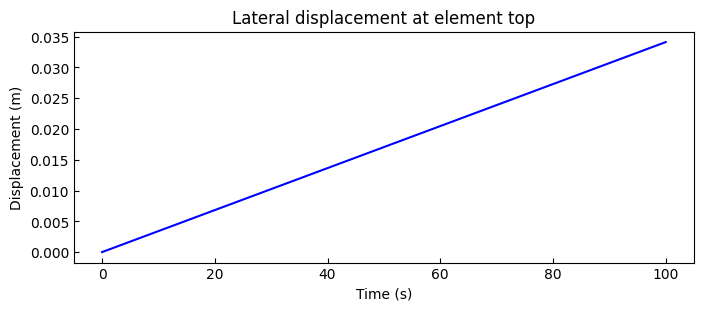

In [72]:
disp1 = node_resp["disp"].sel(nodeTags=1, DOFs="UX").values
disp3 = node_resp["disp"].sel(nodeTags=3, DOFs="UX").values
times = node_resp["time"].data
print(disp3)
fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, disp3, "b")
ax.set_title("Lateral displacement at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Displacement (m)")
plt.show()

In [73]:
from scipy.interpolate import interp1d


t = np.linspace(0, 20 * np.pi, int(20 * np.pi / (np.pi / 50)) + 1)
s = 2 * np.sin(t)
s = np.concatenate((s, np.zeros(3000)))
x_original = np.linspace(0, 40, len(s))
interp_func = interp1d(x_original, s, kind="linear", fill_value="extrapolate")
s1 = interp_func(times)

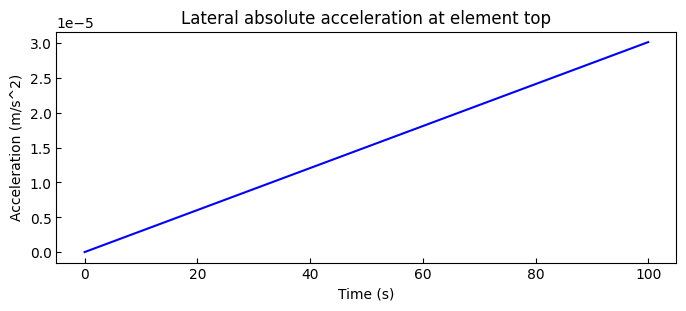

In [74]:
acc3 = node_resp["accel"].sel(nodeTags=3, DOFs="UX")
times = node_resp["time"].data

fig, ax = plt.subplots(1, 1, figsize=(8, 3))
ax.plot(times, s1 + acc3, "b")
ax.set_title("Lateral absolute acceleration at element top")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Acceleration (m/s^2)")
plt.show()

[0. 0.]


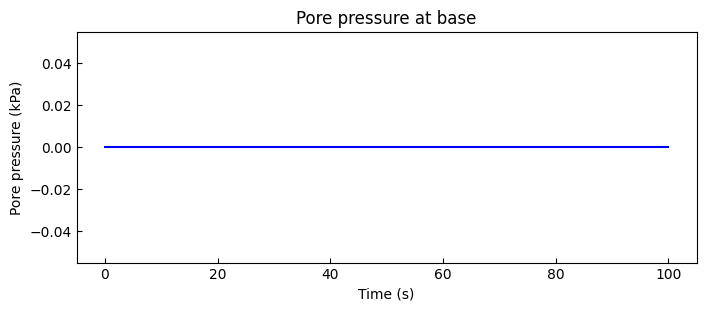

In [75]:
p1 = node_resp["vel"].sel(nodeTags=1, DOFs="RZ")
print(p1.values)
fig, ax = plt.subplots(1, 1, figsize=(8, 3))

ax.plot(times, p1, "b")
ax.set_title("Pore pressure at base")
ax.set_xlabel("Time (s)")
ax.set_ylabel("Pore pressure (kPa)")
plt.show()

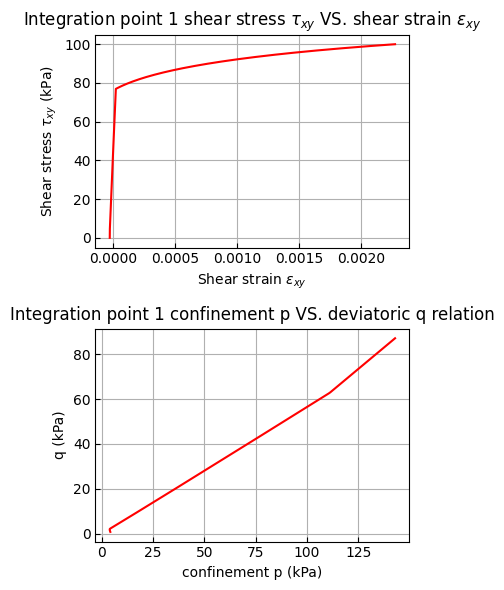

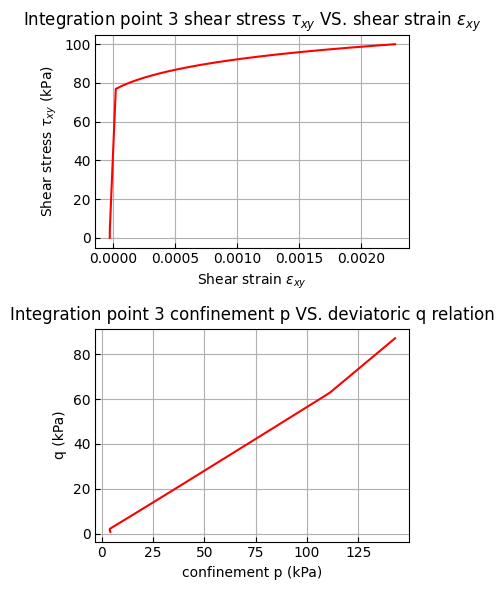

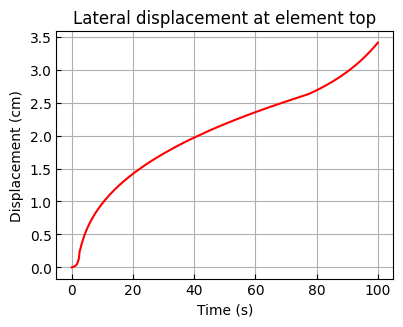

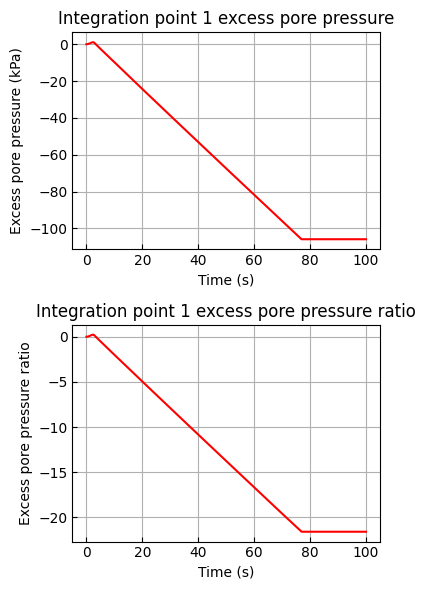

In [76]:
import numpy as np
import matplotlib.pyplot as plt

# --- 1. Load the data from files ---
a1 = np.loadtxt('cacce.out')
d1 = np.loadtxt('cdisp.out')
s1 = np.loadtxt('cstress1.out')
e1 = np.loadtxt('cstrain1.out')
s5 = np.loadtxt('cstress3.out')
e5 = np.loadtxt('cstrain3.out')
p1 = np.loadtxt('cpress1.out')
p3 = np.loadtxt('cpress3.out')

# Define global variables
fs = [0., 0.2, 4, 6]  # [left, bottom, width, height] for paperposition

# --- 2. Helper function for p-q calculations and plotting ---
def plot_stress_strain_and_pq(stress_data, strain_data, figure_num, title_suffix, filename):
    """
    Plots the shear stress vs. shear strain and confinement vs. deviatoric stress.

    Parameters:
    - stress_data (np.ndarray): The stress data matrix.
    - strain_data (np.ndarray): The strain data matrix.
    - figure_num (int): The figure number for the plot.
    - title_suffix (str): A string for the plot titles.
    - filename (str): The base name for saving the figure.
    """
    # Calculate p (mean normal stress)
    po = (stress_data[:, 1] + stress_data[:, 2] ) / 2.0

    # Calculate q (deviatoric stress)
    term1 = (stress_data[:, 1] - stress_data[:, 2])**2
    term2 = (stress_data[:, 2] - stress_data[:, 1])**2
    
    term4 = 6.0 * stress_data[:, 3]**2
    qo = np.sqrt(term1 + term2 + term4) / 3.0
    
    # Apply the sign of s_xy (stress_data[:, 4]) to qo
    qo = np.sign(stress_data[:, 3]) * qo

    # Create the figure and subplots
    plt.figure(figure_num, figsize=(fs[2], fs[3]))
    plt.clf()
    
    # Subplot 1: Shear stress vs. shear strain
    plt.subplot(2, 1, 1)
    plt.plot(strain_data[:, 2], stress_data[:, 3], 'r')
    plt.title(f'{title_suffix} shear stress $\\tau_{{xy}}$ VS. shear strain $\\epsilon_{{xy}}$')
    plt.xlabel('Shear strain $\\epsilon_{{xy}}$')
    plt.ylabel('Shear stress $\\tau_{{xy}}$ (kPa)')
    plt.grid(True)

    # Subplot 2: Confinement vs. deviatoric stress
    plt.subplot(2, 1, 2)
    plt.plot(-po, qo, 'r')
    plt.title(f'{title_suffix} confinement p VS. deviatoric q relation')
    plt.xlabel('confinement p (kPa)')
    plt.ylabel('q (kPa)')
    plt.grid(True)
    
    plt.tight_layout()
    plt.savefig(f'{filename}.jpg', dpi=300)

# --- 3. Plotting the data for different integration points ---
plot_stress_strain_and_pq(s1, e1, 1, 'Integration point 1', 'SS_PQ1')
plot_stress_strain_and_pq(s5, e5, 4, 'Integration point 3', 'SS_PQ5')

# --- 4. Plotting displacement data ---
plt.figure(2, figsize=(fs[2], fs[3]))
plt.clf()
# Note: The MATLAB code has a subplot(2,1,1) but only one plot.
# We'll replicate that structure.
plt.subplot(2, 1, 1)
plt.plot(d1[:, 0], d1[:, 5] * 100, 'r')
plt.title('Lateral displacement at element top')
plt.xlabel('Time (s)')
plt.ylabel('Displacement (cm)')
plt.grid(True)
plt.tight_layout()
plt.savefig('D.jpg', dpi=300)

# --- 5. Plotting pore pressure data ---
plt.figure(5, figsize=(fs[2], fs[3]))
plt.clf()

# Subplot 1: Excess pore pressure
plt.subplot(2, 1, 1)
plt.plot(p1[:, 0], -p1[:, 1], 'r')
plt.title('Integration point 1 excess pore pressure')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure (kPa)')
plt.grid(True)

# Subplot 2: Excess pore pressure ratio
plt.subplot(2, 1, 2)
plt.plot(p1[:, 0], p1[:, 2], 'r')
plt.title('Integration point 1 excess pore pressure ratio')
plt.xlabel('Time (s)')
plt.ylabel('Excess pore pressure ratio')
plt.grid(True)

plt.tight_layout()
plt.savefig('EPWP.jpg', dpi=300)

plt.show()

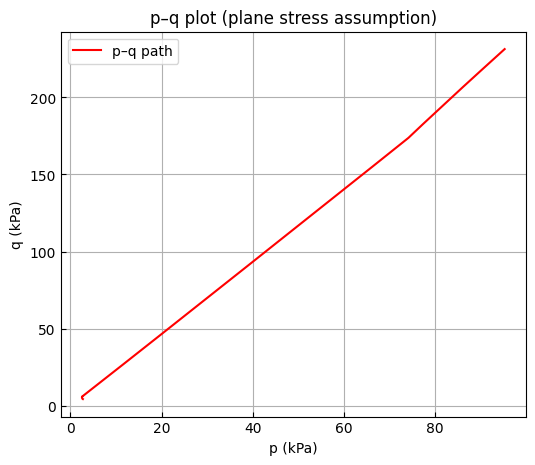

In [77]:
import numpy as np
import matplotlib.pyplot as plt

# Load file
data = np.loadtxt("cstress3.out")

time = data[:,0]
sigma_xx = data[:,1]   # σ11
sigma_yy = data[:,2]   # σ22
tau_xy   = data[:,3]   # τ12

# Plane stress assumption: σzz = 0
sigma_zz = np.zeros_like(sigma_xx)

# Mean stress p
p = (sigma_xx + sigma_yy + sigma_zz) / 3.0

# Deviatoric components
s_xx = sigma_xx - p
s_yy = sigma_yy - p
s_zz = sigma_zz - p
s_xy = tau_xy
s_yz = np.zeros_like(s_xx)
s_zx = np.zeros_like(s_xx)

# J2 invariant
J2 = 0.5 * (s_xx**2 + s_yy**2 + s_zz**2 +2*(s_xy**2 + s_yz**2 + s_zx**2))

# Deviatoric stress q
q = np.sqrt(3.0 * J2)

# Optional: sign for shear direction
q_signed = np.sign(tau_xy) * q

# --- Plot ---
plt.figure(figsize=(6,5))
plt.plot(-p, q_signed, 'r-', label='p–q path')
plt.xlabel('p (kPa)')
plt.ylabel('q (kPa)')
plt.title('p–q plot (plane stress assumption)')
plt.legend()
plt.grid(True)
plt.show()
